In [1]:
print("hello")

hello


In [2]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

UP = 0
DOWN = 1
LEFT = 2
RIGHT = 3

actions = [UP, DOWN, LEFT, RIGHT]

# state = (row, col, has_package, delivered)

ModuleNotFoundError: No module named 'numpy'

In [3]:
import sys
!{sys.executable} -m pip install numpy matplotlib pygame

  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 25.2 MB/s  0:00:00 eta 0:00:01
Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 25.0 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 25.4 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [matplotlib]9 [matplotlib]

[notice] A new release of pip is available: 26.0 ->

In [4]:
from warehouse_gridworld_domain_random import WarehouseGridWorld 

env = WarehouseGridWorld()

state = env.reset()
print("Initial state:", state)

Initial state: (6, 0, 0, 0)


In [6]:
result = env.step("up")

print("Next state:", result.state)
print("Reward:", result.reward)
print("Done:", result.done)
print("Info:", result.info)

Next state: (4, 0, 0, 0)
Reward: -1
Done: False
Info: {'event': 'move'}


In [8]:
Q = {}

def get_q_value(state, action):
    return Q.get((state, action), 0.0)

def set_q_value(state, action, value):
    Q[(state, action)] = value

In [9]:
print(get_q_value(state, "up"))

0.0


In [10]:
def choose_action(state, epsilon):
    
    # get valid actions from environment
    valid_actions = env.valid_actions(state)
    
    # explore
    if random.random() < epsilon:
        return random.choice(valid_actions)
    
    # exploit (best Q value)
    q_values = [get_q_value(state, a) for a in valid_actions]
    max_q = max(q_values)
    
    # handle ties randomly
    best_actions = [a for a in valid_actions if get_q_value(state, a) == max_q]
    
    return random.choice(best_actions)

In [11]:
def update_q_value(state, action, reward, next_state, alpha, gamma):
    
    current_q = get_q_value(state, action)

    next_actions = env.valid_actions(next_state)
    if next_actions:
        max_future_q = max([get_q_value(next_state, a) for a in next_actions])
    else:
        max_future_q = 0

    new_q = current_q + alpha * (reward + gamma * max_future_q - current_q)

    set_q_value(state, action, new_q)

In [12]:
alpha = 0.1
gamma = 0.9
epsilon = 0.2

episodes = 500
max_steps = 50

rewards_per_episode = []

for episode in range(episodes):
    
    state = env.reset()
    total_reward = 0

    for step in range(max_steps):
        
        action = choose_action(state, epsilon)
        
        result = env.step(action)
        next_state = result.state
        reward = result.reward
        done = result.done

        update_q_value(state, action, reward, next_state, alpha, gamma)

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)

In [13]:
print(rewards_per_episode[:10])

[-120, -50, -90, -45, -90, -50, -50, -60, -80, -25]


In [14]:
policy = {}

for state_action in Q:
    state, action = state_action
    if state not in policy or Q[(state, action)] > get_q_value(state, policy[state]):
        policy[state] = action

print(policy)

{(6, 0, 0, 0): 'up', (6, 1, 0, 0): 'left', (5, 0, 0, 0): 'up', (5, 1, 0, 0): 'up', (4, 0, 0, 0): 'right', (7, 0, 0, 0): 'up', (8, 0, 0, 0): 'up', (9, 0, 0, 0): 'up', (6, 2, 0, 0): 'left', (6, 3, 0, 0): 'left', (6, 4, 0, 0): 'down', (7, 4, 0, 0): 'down', (4, 1, 0, 0): 'right', (4, 2, 0, 0): 'right', (4, 3, 0, 0): 'up', (4, 4, 0, 0): 'left', (4, 5, 0, 0): 'left', (3, 5, 0, 0): 'up', (2, 5, 0, 0): 'down', (7, 2, 0, 0): 'down', (8, 2, 0, 0): 'right', (8, 3, 0, 0): 'left', (8, 4, 0, 0): 'left', (9, 3, 0, 0): 'right', (9, 4, 0, 0): 'up', (9, 5, 0, 0): 'left', (9, 2, 0, 0): 'left', (9, 1, 0, 0): 'right', (9, 6, 0, 0): 'right', (9, 7, 0, 0): 'left', (8, 6, 0, 0): 'up', (8, 7, 0, 0): 'left', (9, 8, 0, 0): 'up', (8, 8, 0, 0): 'up', (7, 8, 0, 0): 'right', (6, 8, 0, 0): 'right', (6, 9, 0, 0): 'down', (5, 9, 0, 0): 'up', (3, 3, 0, 0): 'up', (2, 3, 0, 0): 'left', (2, 2, 1, 0): 'right', (2, 1, 1, 0): 'right', (1, 1, 1, 0): 'down', (2, 3, 1, 0): 'up', (1, 3, 1, 0): 'up', (3, 3, 1, 0): 'up', (4, 3, 1, 

In [15]:
state = env.reset()

print("Demo run:")

for step in range(20):
    
    action = policy.get(state, None)
    
    if action is None:
        break

    result = env.step(action)
    
    print(f"State: {state}, Action: {action}, Reward: {result.reward}")
    
    state = result.state

    if result.done:
        print("Reached goal!")
        break

Demo run:
State: (6, 0, 0, 0), Action: up, Reward: -1
State: (5, 0, 0, 0), Action: up, Reward: -1
State: (4, 0, 0, 0), Action: right, Reward: -1
State: (4, 1, 0, 0), Action: right, Reward: -1
State: (4, 2, 0, 0), Action: right, Reward: -1
State: (4, 3, 0, 0), Action: up, Reward: -1
State: (3, 3, 0, 0), Action: up, Reward: -1
State: (2, 3, 0, 0), Action: left, Reward: 24
State: (2, 2, 1, 0), Action: right, Reward: -1
State: (2, 3, 1, 0), Action: up, Reward: -1
State: (1, 3, 1, 0), Action: up, Reward: -1
State: (0, 3, 1, 0), Action: right, Reward: 39
State: (0, 4, 1, 1), Action: left, Reward: -1
State: (0, 3, 1, 1), Action: down, Reward: -1
State: (1, 3, 1, 1), Action: down, Reward: -1
State: (2, 3, 1, 1), Action: down, Reward: -1
State: (3, 3, 1, 1), Action: down, Reward: -1
State: (4, 3, 1, 1), Action: left, Reward: -1
State: (4, 2, 1, 1), Action: left, Reward: -1
State: (4, 1, 1, 1), Action: left, Reward: -1


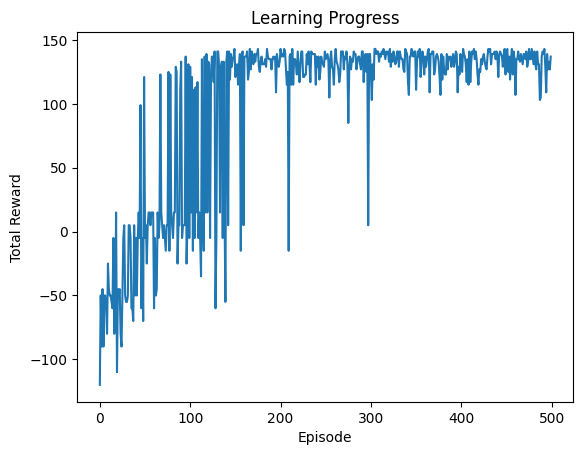

In [16]:
import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)
plt.title("Learning Progress")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()